In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

small_llm = ChatOpenAI(model="gpt-4o-mini")

In [4]:
from langchain_core.tools import tool


# tool 구성에는 세가지 구성이 필요하다
# 1. decorater (@tool)
# 2. description ("해당 툴의 설명")
# 3. expected arg ("인자")
@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a+b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a*b


In [5]:
%pip install -U duckduckgo-search
%pip install -qU langchain-google-community\[gmail\]


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

In [7]:
from langchain_google_community import GmailToolkit
from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/token.json",
    scopes=["https://mail.google.com/"],
    client_secrets_file="./google/credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gamil_tool_list = gmail_toolkit.get_tools()

In [8]:
%pip install arxiv
%pip install pymupdf


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
from langchain.agents import load_tools

loaded_tool_list = load_tools(["arxiv"])

In [10]:
import os

from langchain_chroma import Chroma
from langchain_core.tools.retriever import create_retriever_tool
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='real_estate_tax',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to December 2024',
)

In [11]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gamil_tool_list + loaded_tool_list
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode(tools=tool_list)


In [12]:
from langgraph.graph import MessagesState, StateGraph
# 내장 state 사용
graph_builder = StateGraph(MessagesState)

In [24]:
from langgraph.graph import MessagesState, StateGraph
from langchain_core.messages import SystemMessage

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

def agent(state: AgentState) -> AgentState:
    # 메시지와 요약을 state에서 가져옵니다.
    messages = state['messages']
    summary = state['summary']
    
    # 요약이 비어있지 않으면, 요약을 메시지 앞에 추가합니다.
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
    
    # LLM과 도구를 사용하여 메시지에 대한 응답을 생성합니다.
    response = llm_with_tools.invoke(messages)
    
    # 응답 메시지를 포함하는 새로운 state를 반환합니다.
    return {'messages': [response]}

In [25]:
def summarize_messages(state: AgentState) -> AgentState:
    # state에서 메시지와 요약을 가져옵니다.
    messages = state['messages']
    summary = state['summary']
    
    # 요약 프롬프트를 생성합니다.
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    
    # 기존 요약이 있으면, 요약을 포함한 프롬프트를 생성합니다.
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
chat_history:{messages}
summary:{summary}'''
    
    # LLM을 사용하여 요약을 생성합니다.
    summary = small_llm.invoke(summary_prompt)
    
    # 요약된 메시지를 반환합니다.
    return {'summary': summary.content}

In [ ]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: AgentState) -> AgentState:
    # state에서 메시지를 가져옵니다.
    messages = state['messages']
    # 마지막 세 개의 메시지를 제외한 나머지 메시지를 삭제합니다.
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    # 삭제된 메시지를 포함하는 새로운 state를 반환합니다.
    return {'messages': delete_messages}

In [ ]:
from typing import Literal

def should_continue(state: AgentState) -> Literal['tools', 'summarize_messages']:
    # state에서 메시지를 가져옵니다.
    messages = state['messages']
    # 마지막 AI 메시지를 확인합니다.
    last_ai_message = messages[-1]
    
    # 마지막 AI 메시지가 도구 호출을 포함하고 있는지 확인합니다.
    if last_ai_message.tool_calls:
        # 도구 호출이 있으면 'tools'를 반환합니다.
        return 'tools'
    
    # 도구 호출이 없으면 'summarize_messages'를 반환합니다.
    return 'summarize_messages'

In [26]:
# 노드 추가
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(delete_messages)
graph_builder.add_node(summarize_messages)

# shoud_continue는 conditional edge에서 분간하기 떄문에 노드로는 추가하지 않음 

In [27]:
from langgraph.graph import START, END


graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

In [28]:
from langgraph.checkpoint.memory import MemorySaver

# 채팅 히스토리 관리
checkPointer = MemorySaver()

graph = graph_builder.compile(
    checkpointer=checkPointer
)

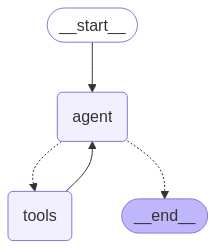

In [29]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'test_thread'
    }
}

# stream 모드로 실행해 agent가 어떤식으로 동작하는지 확인
# small_llm 모델로 실행하면 메일을 보내지 않고 draft만 생성함 -> 채팅 히스토리 관리가 전혀 안되기 떄문에
# 조금 큰 모델로 실행하면 메일을 보내고 보낸 메일을 확인할 수 있음
for chunk in graph.stream({'messages': [HumanMessage('어제의 나스닥 수익률을 알려주세요')], 'summary': ''}, stream_mode='values', config=config):
    chunk['messages'][-1].pretty_print()


================================ Human Message =================================

어제의 나스닥 수익률을 알려주세요
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_froc9DGcFIK5ZytYJHyc5pem)
 Call ID: call_froc9DGcFIK5ZytYJHyc5pem
  Args:
    query: Nasdaq yesterday performance
    max_results: 1
================================= Tool Message =================================
Name: duckduckgo_search

Discover real-time NASDAQ Composite Index (COMP) share prices, quotes, historical data, news, and Insights for informed trading and investment decisions. Stay ahead with Nasdaq. The closing price for the Nasdaq Composite (IXIC) yesterday was $17,231.49. It was up 1.1% for the day (down 0.5% from previous close). Explore the latest stock market trends and compare key indexes including Nasdaq Composite, Nasdaq-100, and Dow Jones Industrial. The closing price for the Nasdaq Composite (IXIC) yesterday was $15,616.12. It was up 4.2% for the

In [31]:
from langchain_core.messages import HumanMessage

other_query = "오늘의 나스닥 수익이랑 비교하면 얼마나 차이나나요 "
for chunk in graph.stream({'messages': [HumanMessage(other_query)]}, stream_mode='values', config=config):
    chunk['messages'][-1].pretty_print()


================================ Human Message =================================

오늘의 나스닥 수익이랑 비교하면 얼마나 차이나나요 
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_poNzepzKJclqMXNRO1cU0Vu9)
 Call ID: call_poNzepzKJclqMXNRO1cU0Vu9
  Args:
    query: Nasdaq current performance
    max_results: 1
================================= Tool Message =================================
Name: duckduckgo_search

Explore the latest stock market trends and compare key indexes including Nasdaq Composite, Nasdaq-100, and Dow Jones Industrial. NASDAQ 100 Today: Get all information on the NASDAQ 100 Index including historical chart, news and constituents. NASDAQ 100 Today: Get all information on the NASDAQ 100 Index including historical chart, news and constituents. NASDAQ 100 INDEXindex chart, prices and performance, plus recent news and analysis. Get NASDAQ 100 INDEX (.NDX) real-time stock quotes, news, price and financial information from

히스토리 관리 시, 그대로 사용하게 되면 토큰을 너무 많이 소비하게 된다. 따라서 히스토리를 관리해야 한다.

1. 오래된 히스토리를 삭제한다.
2. 히스토리를 요약해서 LLM에 넘겨준다.

In [32]:
from langchain_core.messages import RemoveMessage

# 수동 히스토리 삭제
message_list = graph.get_state(config).values['messages']
for message, index in enumerate(message_list):
    if index > 3:
        message_list[index] = RemoveMessage()

TypeError: '>' not supported between instances of 'HumanMessage' and 'int'

In [ ]:
# 노드를 추가해 히스토리 삭제
# def delete_messages(state: MessagesState):
#     messages = state['messages']
#     delete_messages = [RemoveMessage(id=messages.id) for message in messages[:-3]]
#     return {'messages': delete_messages}


# def should_continue(state: MessagesState):
#     messages = state['messages']
#     last_ai_message = messages[-1]
#     if last_ai_message.tool_calls:
#         return 'tools'
#     return 'delete_messages'

# graph_builder.add_conditional_edges(
#     "agent",
#     should_continue,
#     ['tools', 'delete_messages']
# )
# graph_builder.add_edge("delete_messages", END)



In [ ]:
# 요약으로 히스토리 관리

# from langgraph.graph import MessagesState, MessageGraph

# # summary 필드가 있는 AgentState 클래스 정의
# class AgentState(MessagesState):
#     summary: str

# # 이후 각 노드의 state를 AgentState로 선언
# def summarize_messages(state: AgentState) -> AgentState:
#     """
#     주어진 state의 메시지를 요약합니다.

#     Args:
#         state (AgentState): 메시지와 요약을 포함하는 state.

#     Returns:
#         AgentState: 요약된 메시지를 포함하는 딕셔너리.
#     """
#     # state에서 메시지와 요약을 가져옵니다.
#     messages = state['messages']
#     summary = state['summary']
    
#     # 요약 프롬프트를 생성합니다.
#     summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    
#     # 기존 요약이 있으면, 요약을 포함한 프롬프트를 생성합니다.
#     if summary != '':
#         summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
# chat_history:{messages}
# summary:{summary}'''
    
#     # LLM을 사용하여 요약을 생성합니다.
#     summary = small_llm.invoke(summary_prompt)
    
#     # 요약된 메시지를 반환합니다.
#     return {'summary': summary.content}